<h1 align="center"> Network science and Graph Learning </h1>


In [ ]:
from abc import ABC, abstractmethod
import community as community_louvain
import glob
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import random
from sklearn.metrics import accuracy_score
from sklearn.metrics import normalized_mutual_info_score, homogeneity_score
import torch

## Question 2: Social Network Analysis with the Facebook100 Dataset


In [33]:
def analyze_and_compute_function(gml_path, graph_label):
    G = nx.read_gml(gml_path, label='id')

    degrees = [d for _, d in G.degree()]
    local_clustering = nx.clustering(G)
    local_clust_values = list(local_clustering.values())
    global_clustering = nx.transitivity(G)
    mean_local_clustering = np.mean(local_clust_values)
    edge_density = nx.density(G)

    print(f"\n=== {graph_label} ===")
    print(f"Global clustering coefficient: {global_clustering:.4f}")
    print(f"Mean local clustering coefficient: {mean_local_clustering:.4f}")
    print(f"Edge density: {edge_density:.4f}")

    plt.figure(figsize=(6,4))
    degree_values, counts = np.unique(degrees, return_counts=True)
    plt.plot(degree_values, counts, 'o-')
    plt.title(f"Degree Distribution - {graph_label}")
    plt.xlabel("Degree")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.scatter(degrees, local_clust_values, alpha=0.5)
    plt.title(f"Degree vs Local Clustering - {graph_label}")
    plt.xlabel("Degree")
    plt.ylabel("Local Clustering Coefficient")
    plt.grid(True)
    plt.show()



=== Caltech36 ===
Global clustering coefficient: 0.2913
Mean local clustering coefficient: 0.4093
Edge density: 0.0564


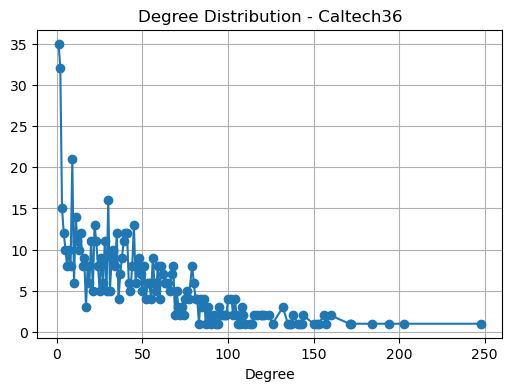

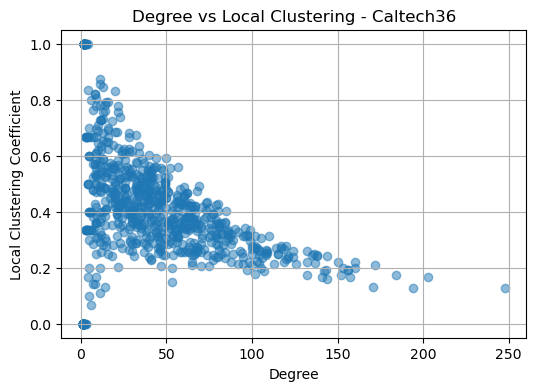


=== Johns Hopkins55 ===
Global clustering coefficient: 0.1932
Mean local clustering coefficient: 0.2684
Edge density: 0.0139


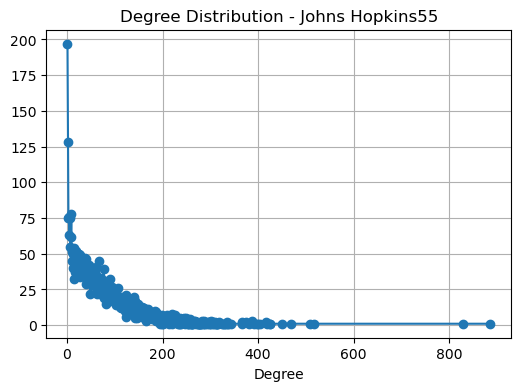

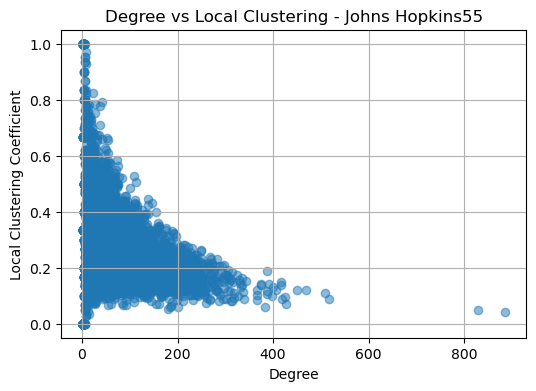


=== MIT8 ===
Global clustering coefficient: 0.1803
Mean local clustering coefficient: 0.2712
Edge density: 0.0121


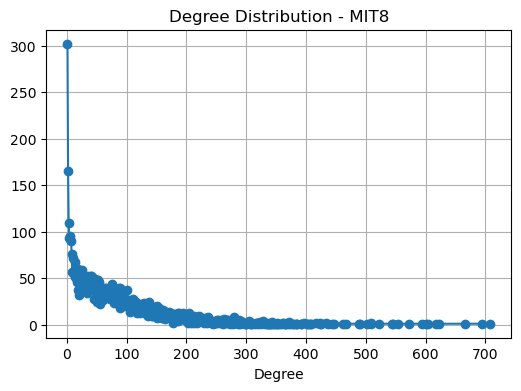

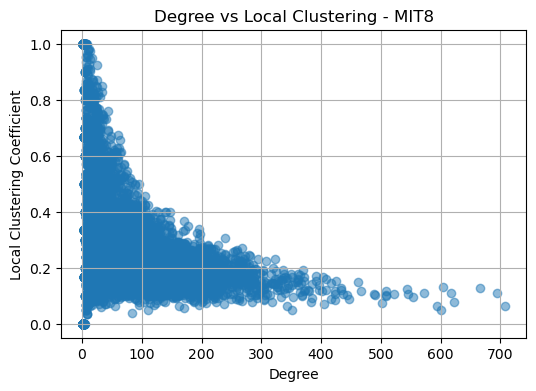

In [43]:
graph_files = [
    ("data/Caltech36.gml", "Caltech36"),
    ("data/Johns Hopkins55.gml", "Johns Hopkins55"),
    ("data/MIT8.gml", "MIT8")
]

for path, label in graph_files:
    analyze_and_compute_function(path, label)


## Question 3: Assortativity Analysis with the Facebook100 Dataset


In [8]:
data_folder = "data/"
files = glob.glob(os.path.join(data_folder, "*.gml"))

network_files = {
    os.path.splitext(os.path.basename(path))[0]: path for path in files
}

attributes = ['gender', 'major_index', 'dorm', 'student_fac', 'year']

results = {attr: [] for attr in attributes}
sizes = []

missing_attr_log = []

for name, file_path in network_files.items():
    G = nx.read_gml(file_path, label='id')
    sizes.append(G.number_of_nodes())

    for attr in attributes:
        assort = nx.attribute_assortativity_coefficient(G, attr)
        results[attr].append(assort)

### Plot Assortativity

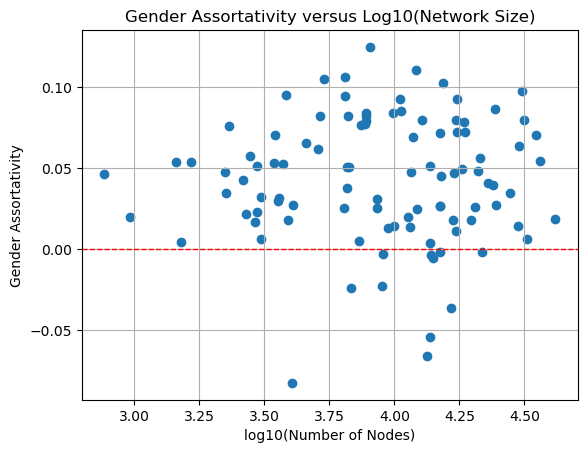

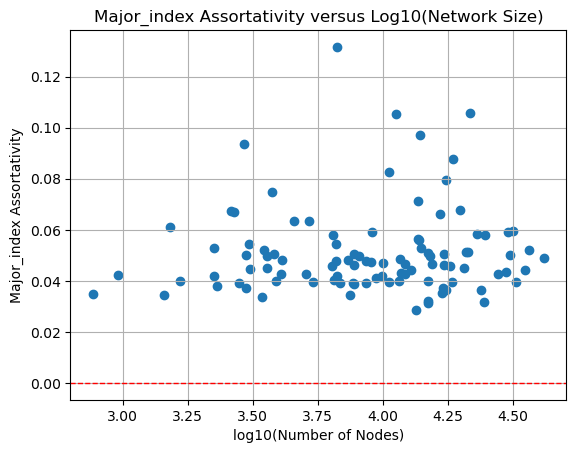

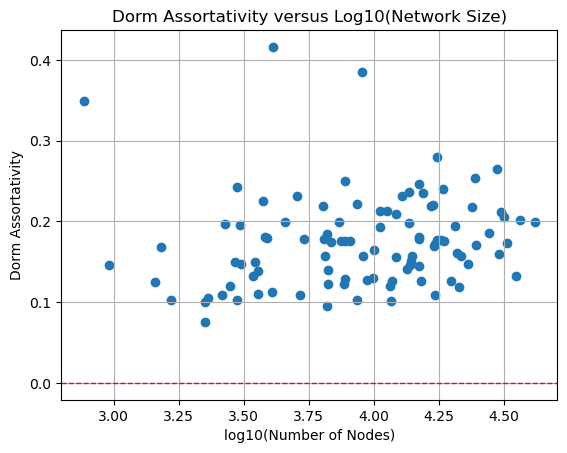

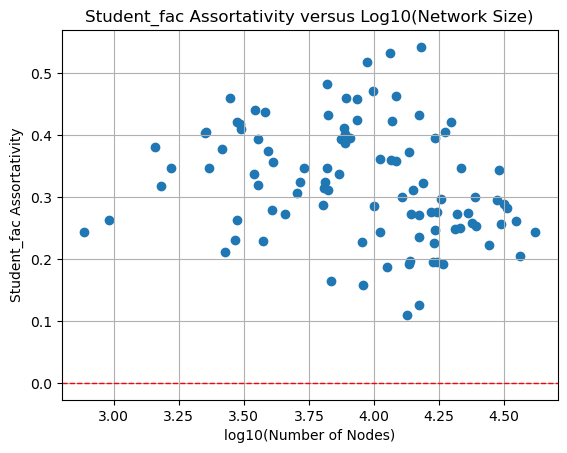

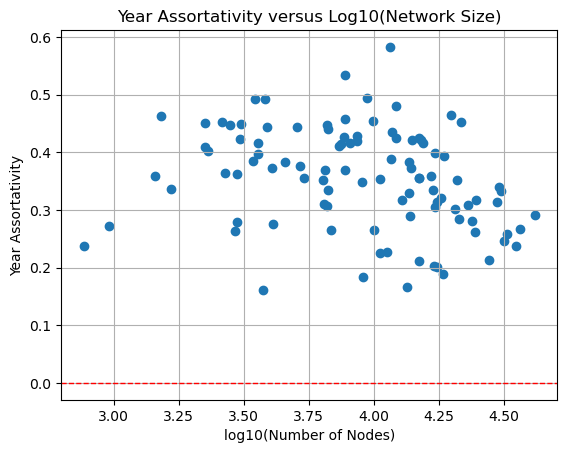

In [9]:
for attr in attributes:
    x = []
    y = []
    for size, val in zip(sizes, results[attr]):
        if val is not None and not np.isnan(val):
            x.append(np.log10(size))
            y.append(val)

    plt.figure()
    plt.scatter(x, y)
    plt.title(f"{attr.capitalize()} Assortativity versus Log10(Network Size)")
    plt.xlabel("log10(Number of Nodes)")
    plt.ylabel(f"{attr.capitalize()} Assortativity")
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.grid(True)
    plt.show()

### Plot Histograms

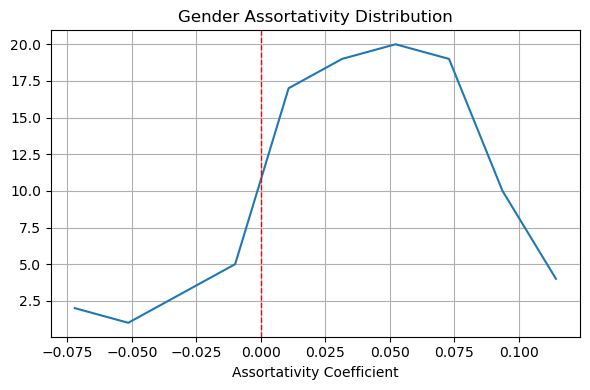

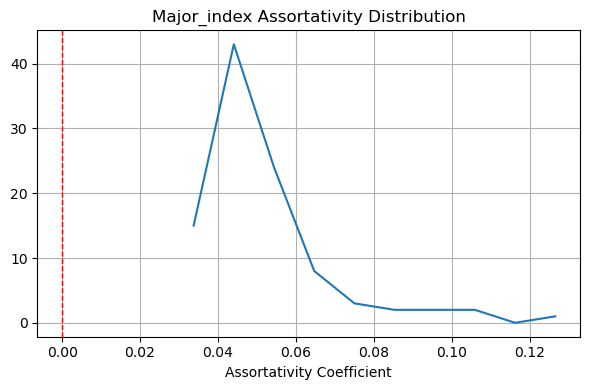

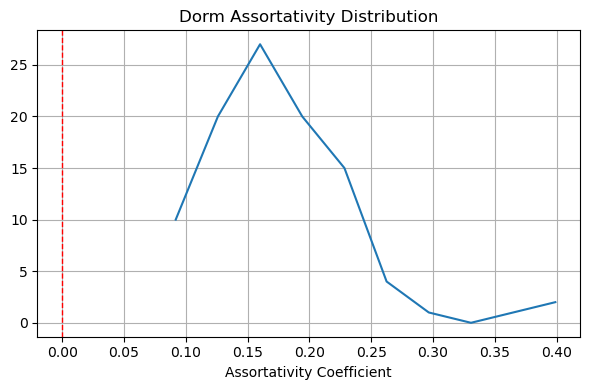

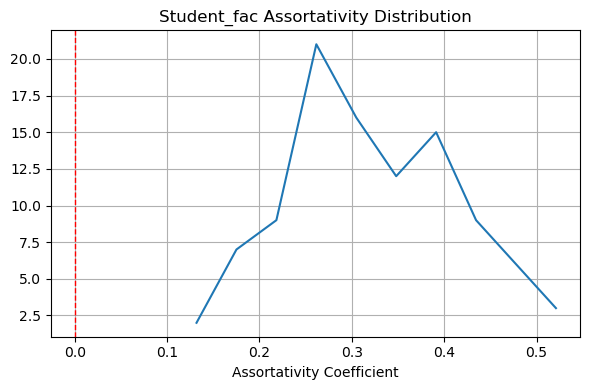

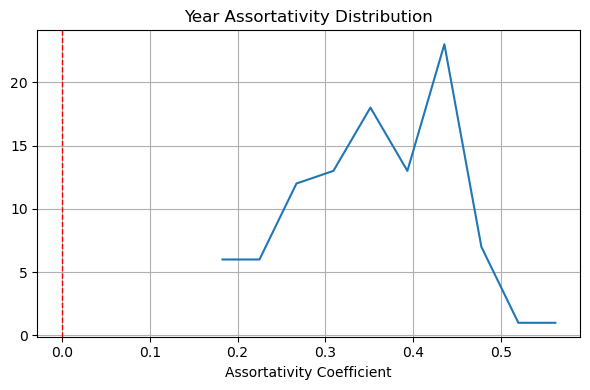

In [31]:
for attr in attributes:
    vals = [v for v in results[attr] if v is not None]
    counts, bins = np.histogram(vals, bins=10)
    centers = (bins[:-1] + bins[1:]) / 2
    plt.figure(figsize=(6,4))
    plt.plot(centers, counts)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.title(f"{attr.capitalize()} Assortativity Distribution")
    plt.xlabel("Assortativity Coefficient")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Question 4: Link prediction

### Python implementation of a Link prediction metric

In [35]:
class LinkPrediction(ABC):
    def __init__(self, graph):
        """
        Constructor

        Parameters
        ----------
        graph : networkx.Graph
            The training graph in which links are known.
        """
        self.graph = graph
        self.N = graph.number_of_nodes()

    def neighbors(self, v):
        """
            Return the neighbors list of a node

            Parameters
            ----------
                v: int
                    node id

            Return
            ------
                neighbors_list : python list
        """
        return list(self.graph.neighbors(v))

    @abstractmethod
    def fit(self):
        raise NotImplementedError("fit() must be implemented")

    @abstractmethod
    def score(self, u, v):
        """
        Compute the link‐prediction score for the node pair (u, v).
        Must be implemented by subclasses.
        """
        pass

    def decision_function(self, pairs):
        """
        Compute a score for each node pair in `pairs`.

        Parameters
        ----------
        pairs : iterable of (u, v) tuples

        Returns
        -------
        np.ndarray of scores
        """
        scores = np.zeros(len(pairs), dtype=float)
        for i, (u, v) in enumerate(pairs):
            scores[i] = self.score(u, v)
        return scores

### Metric implementations


In [36]:
class CommonNeighbors(LinkPrediction):
    def fit(self):
        return self

    def score(self, u, v):
        Nu = set(self.neighbors(u))
        Nv = set(self.neighbors(v))
        return float(len(Nu & Nv))


class Jaccard(LinkPrediction):
    def fit(self):
        return self

    def score(self, u, v):
        Nu = set(self.neighbors(u))
        Nv = set(self.neighbors(v))
        union = Nu | Nv
        if not union:
            return 0.0
        return float(len(Nu & Nv)) / len(union)


class AdamicAdar(LinkPrediction):
    def fit(self):
        return self

    def score(self, u, v):
        common = set(self.neighbors(u)) & set(self.neighbors(v))
        s = 0.0
        for w in common:
            deg = self.graph.degree(w)
            if deg > 1:
                s += 1.0 / np.log(deg)
        return s

### Evaluating a link predictor

In [37]:
def evaluate_link_prediction(G, LPMS, f=0.1, k_list=[50, 100, 200, 300, 400]):
    edges = list(G.edges())
    num_test = int(len(edges) * f)
    test_edges = random.sample(edges, num_test)

    G_train = G.copy()
    G_train.remove_edges_from(test_edges)
    
    for LPM in LPMS:
        predictor = LPM(G_train)
        candidates = [(u, v) for u in G.nodes() for v in G.nodes() if u < v and not G_train.has_edge(u, v)]
        scores = [(predictor.score(u, v), u, v) for u, v in candidates]
        scores.sort(reverse=True)

        true_set = set((min(u, v), max(u, v)) for u, v in test_edges)
        for k in k_list:
            topk = scores[:k]
            predicted = set((min(u, v), max(u, v)) for _, u, v in topk)
            tp = len(predicted & true_set)
            print(f"{LPM.__name__} @ k={k}: precision={tp/k:.3f}, recall={tp/num_test:.3f}")

In [44]:
network_files = {
    'Caltech36': 'data/Caltech36.gml',
    'MIT8': 'data/MIT8.gml',
    'Johns Hopkins55': 'data/Johns Hopkins55.gml'
}

for file in network_files:
    print(f"====\n{file}\n====")
    G = nx.read_gml(network_files[file], label='id')
    evaluate_link_prediction(G, [CommonNeighbors, Jaccard, AdamicAdar])

====
Caltech36
====
CommonNeighbors @ k=50: precision=0.620, recall=0.019
CommonNeighbors @ k=100: precision=0.520, recall=0.031
CommonNeighbors @ k=200: precision=0.475, recall=0.057
CommonNeighbors @ k=300: precision=0.450, recall=0.081
CommonNeighbors @ k=400: precision=0.422, recall=0.102
Jaccard @ k=50: precision=0.480, recall=0.014
Jaccard @ k=100: precision=0.480, recall=0.029
Jaccard @ k=200: precision=0.375, recall=0.045
Jaccard @ k=300: precision=0.363, recall=0.065
Jaccard @ k=400: precision=0.345, recall=0.083
AdamicAdar @ k=50: precision=0.620, recall=0.019
AdamicAdar @ k=100: precision=0.520, recall=0.031
AdamicAdar @ k=200: precision=0.495, recall=0.059
AdamicAdar @ k=300: precision=0.457, recall=0.082
AdamicAdar @ k=400: precision=0.435, recall=0.105
====
MIT8
====
CommonNeighbors @ k=50: precision=0.820, recall=0.002
CommonNeighbors @ k=100: precision=0.800, recall=0.003
CommonNeighbors @ k=200: precision=0.730, recall=0.006
CommonNeighbors @ k=300: precision=0.720, re

## Question 5: Find missing labels with the label propagation algorithms

In [40]:
def convert_graph(nx_graph, target_attr):

    nodes = list(nx_graph.nodes())
    index_of = {node: i for i, node in enumerate(nodes)}
    N = len(nodes)

    A = nx.to_numpy_array(nx_graph, nodelist=nodes)
    degrees = A.sum(axis=1, keepdims=True)
    degrees[degrees == 0] = 1
    A_norm = A / degrees

    labels = np.full((N,), -1, dtype=int)
    attr_map = {}
    for node, idx in index_of.items():
        val = nx_graph.nodes[node].get(target_attr)
        if val is not None:
            if val not in attr_map:
                attr_map[val] = len(attr_map)
            labels[idx] = attr_map[val]

    adj_tensor    = torch.from_numpy(A_norm).float()
    labels_tensor = torch.from_numpy(labels).long()

    return adj_tensor, labels_tensor, attr_map

In [41]:
def propagate_labels(adj_matrix, labels, max_steps=100):
    observed = labels[labels >= 0]
    num_classes = int(observed.max().item()) + 1 if observed.numel() > 0 else 1
    N = adj_matrix.size(0)

    onehot_init = torch.zeros((N, num_classes), dtype=torch.float32)
    known = (labels >= 0)
    onehot_init[known] = torch.nn.functional.one_hot(labels[known], num_classes).float()

    state = onehot_init.clone()

    for _ in range(max_steps):
        state = adj_matrix.matmul(state)
        state[known] = onehot_init[known]

    return state.argmax(dim=1)


def evaluate_propagation(graph, attr_name, missing_frac=0.2, max_steps=100):
    graph_copy = graph.copy()
    nodes_with_label = list()
    
    for node in graph_copy.nodes():
        if graph_copy.nodes[node].get(attr_name) is not None:
            nodes_with_label.append(node)
    masked_nodes = random.sample(
        nodes_with_label, int(len(nodes_with_label) * missing_frac)
    )
    
    original_labels = {n: graph_copy.nodes[n][attr_name] for n in masked_nodes}

    for n in masked_nodes:
        graph_copy.nodes[n][attr_name] = None

    adj, lab_vec, val_map = convert_graph(graph_copy, attr_name)
    predicted = propagate_labels(adj, lab_vec, max_steps)

    node_to_idx = {node: idx for idx, node in enumerate(graph_copy.nodes())}
    true_list = [
        val_map[original_labels[n]]
        for n in masked_nodes
        if original_labels[n] in val_map
    ]
    pred_list = [
        int(predicted[node_to_idx[n]])
        for n in masked_nodes
        if original_labels[n] in val_map
    ]

    accuracy = accuracy_score(true_list, pred_list)
    return accuracy

In [42]:
G = nx.read_gml("data/Duke14.gml")

attributes = ['dorm', 'major_index', 'gender']
fractions  = [0.1, 0.2, 0.3]

header = ["Attribute"] + [f"{int(f*100)}%" for f in fractions]
print(" | ".join(h.center(12) for h in header))
print("-" * (14 * len(header)))

for attr in attributes:
    row = [attr.center(12)]
    for f in fractions:
        acc = evaluate_propagation(G, attr, missing_frac=f)
        row.append(f"{acc:.3f}".center(12))
    print(" | ".join(row))

 Attribute   |     10%      |     20%      |     30%     
--------------------------------------------------------
    dorm     |    0.509     |    0.489     |    0.487    
major_index  |    0.297     |    0.258     |    0.265    
   gender    |    0.640     |    0.614     |    0.620    


## Question 6: Communities detection with the FB100 datasets

In [46]:
def load_graph(path):
    G = nx.read_gml(path)
    return G

def extract_labels(G, attribute):
    labels = []
    for node in G.nodes():
        labels.append(G.nodes[node].get(attribute, -1))
    return labels

def run_louvain(G):
    partition = community_louvain.best_partition(G)
    return [partition[node] for node in G.nodes()]

def evaluate(true_labels, pred_labels):
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    homo = homogeneity_score(true_labels, pred_labels)
    return nmi, homo

def plot_communities(G, partition, title="Communities"):
    pos = nx.spring_layout(G)
    colors = [partition[node] for node in G.nodes()]
    plt.figure(figsize=(8, 6))
    nx.draw_networkx_nodes(G, pos, node_size=30, cmap=plt.cm.jet, node_color=colors)
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    plt.title(title)
    plt.axis('off')
    plt.show()

===== Caltech36 =====
Attribute: dorm | NMI: 0.530 | Homogeneity: 0.519
Attribute: major | NMI: 0.000 | Homogeneity: 1.000


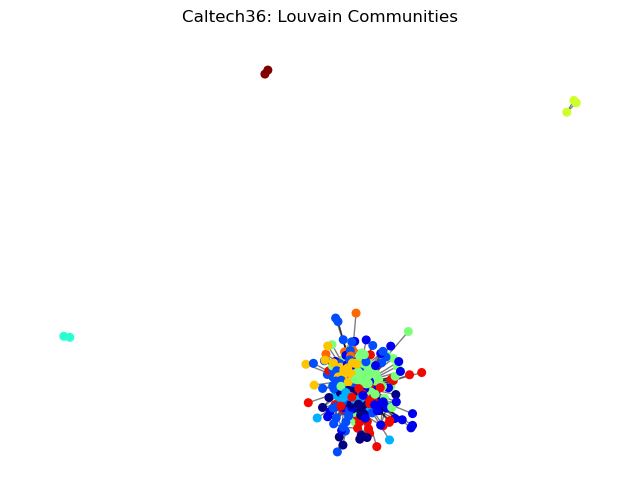

===== MIT8 =====
Attribute: dorm | NMI: 0.248 | Homogeneity: 0.209
Attribute: major | NMI: 0.000 | Homogeneity: 1.000


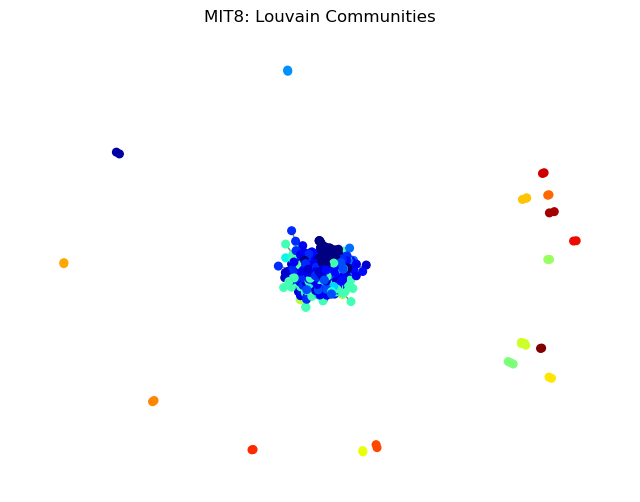

===== Duke14 =====
Attribute: dorm | NMI: 0.237 | Homogeneity: 0.185
Attribute: major | NMI: 0.000 | Homogeneity: 1.000


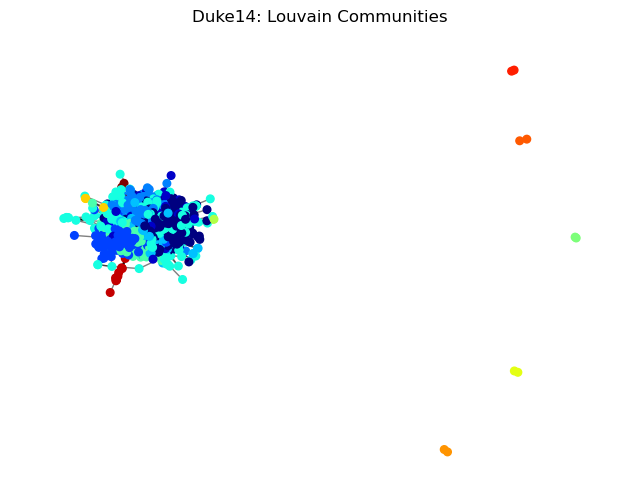

In [45]:
graph_paths = {
    "Caltech36": "data/Caltech36.gml",
    "MIT8": "data/MIT8.gml",
    "Duke14": "data/Duke14.gml"
}
attributes = ["dorm", "major"]

for school, path in graph_paths.items():
    print(f"===== {school} =====")
    G = load_graph(path)
    detected_communities = run_louvain(G)
    
    for attr in attributes:
        true_labels = extract_labels(G, attr)
        nmi, homo = evaluate(true_labels, detected_communities)
        print(f"Attribute: {attr} | NMI: {nmi:.3f} | Homogeneity: {homo:.3f}")
    
    partition = community_louvain.best_partition(G)
    plot_communities(G, partition, title=f"{school}: Louvain Communities")
